# Importing packages

In [1]:
import scimap as sm
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import yaml
from pathlib import Path
from matplotlib import colormaps
import seaborn as sns

Running SCIMAP  2.1.3


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
preprocessed_dir = Path("/Users/jawadalaaedeen/Desktop/PhD/NMC/preprocessed")
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']

In [37]:
#conctenate all the adata files
adata_list = []
for roi in roi_list:
    adata = ad.read_h5ad(roi / "adata.h5ad")
    adata_list.append(adata)
adata = ad.concat(adata_list)

#make obs names unique
adata.obs_names_make_unique()


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning:

Observation names are not unique. To make them unique, call `.obs_names_make_unique`.



/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_9568/1578851348.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



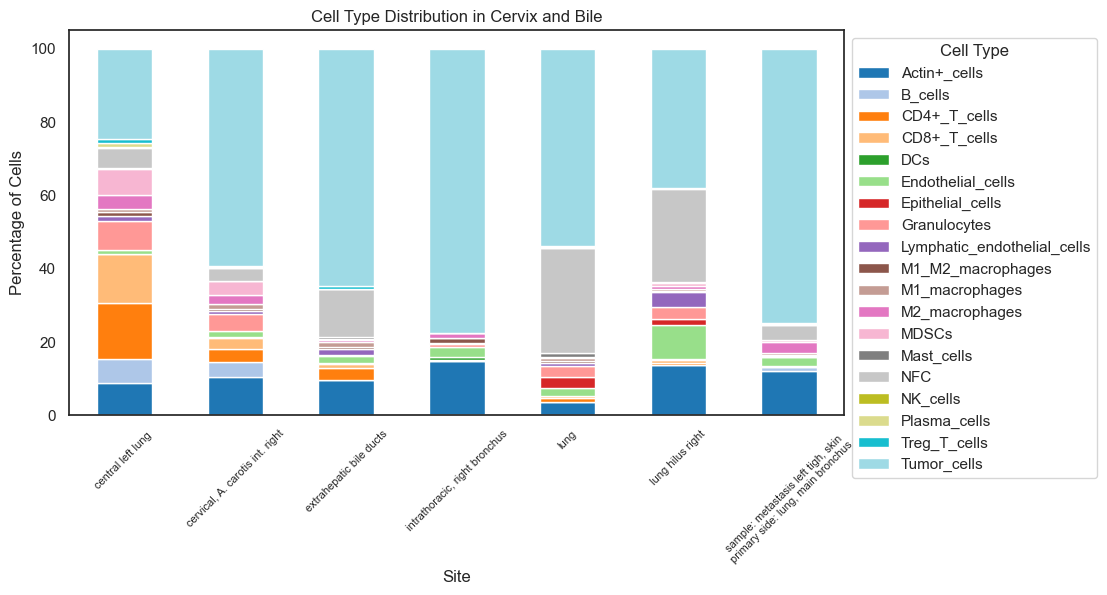

In [4]:
#Let's look at all samples

counts = adata.obs.groupby("site").cell_type.value_counts(normalize=True).mul(100).to_frame().reset_index().pivot(index="site", columns="cell_type", values="proportion").fillna(0)

#make bar plot with legend on the side
plt.figure(figsize=(10, 5))
counts.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab20")
plt.legend(title="Cell Type", bbox_to_anchor=(1, 1))
plt.ylabel("Percentage of Cells")
plt.xlabel("Site")
#make x-axis labels with 45 degrees
plt.xticks(rotation=45)
#make x-axis labels with smaller size
plt.xticks(fontsize=8)
plt.title("Cell Type Distribution in Cervix and Bile")
plt.show()

In [4]:
#correct for batch effects
sc.pp.scale(adata)
adata.X = adata.X.astype(np.float32).copy()
sc.pp.combat(adata, key="exp_name", inplace=True)

In [5]:
#sort adata by patient ID
adata = adata[adata.obs["patient_ID"].sort_values().index]

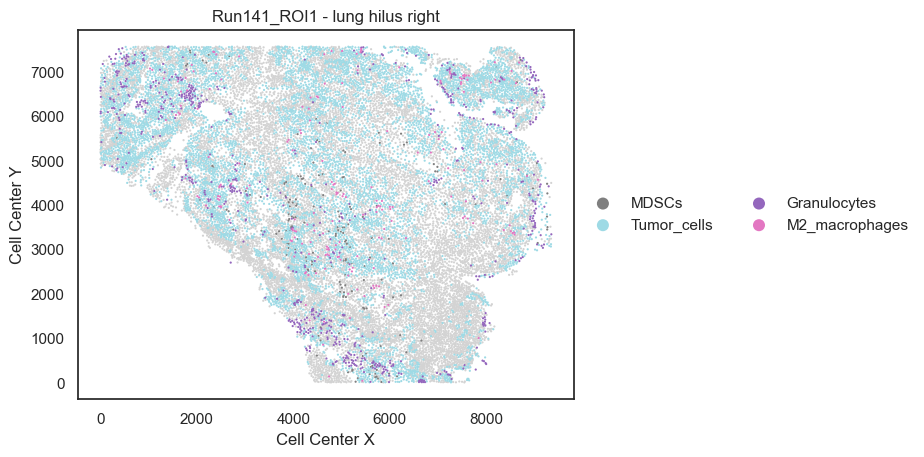

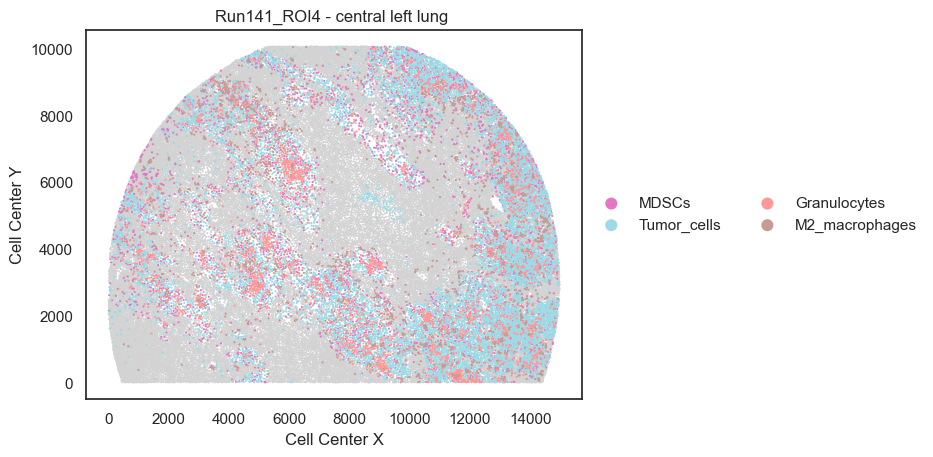

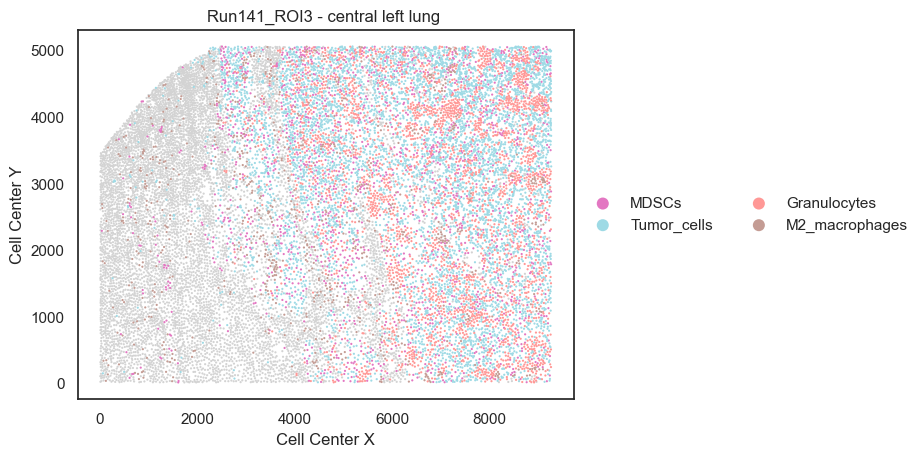

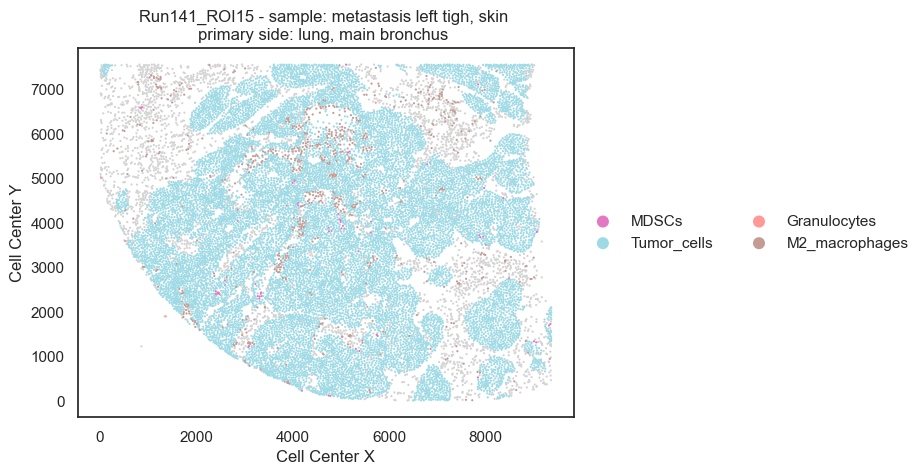

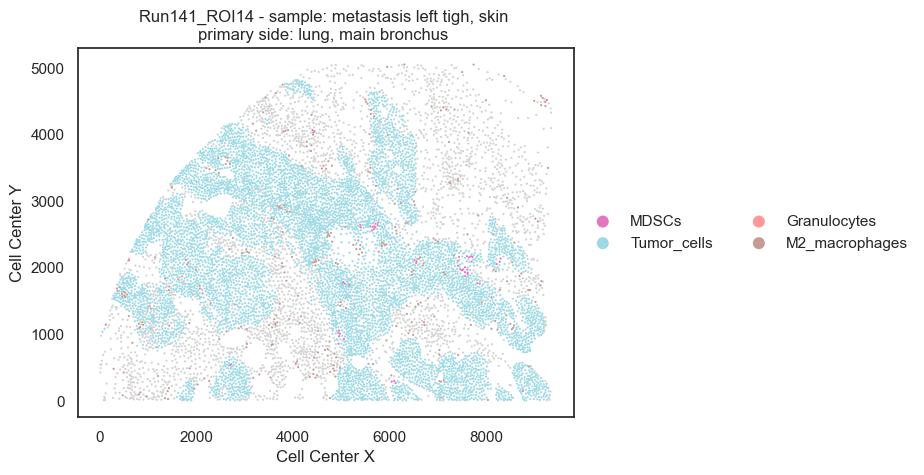

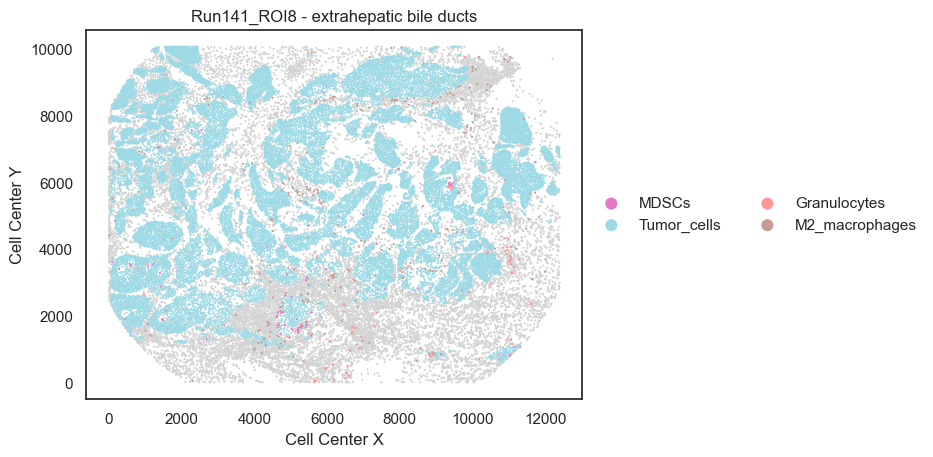

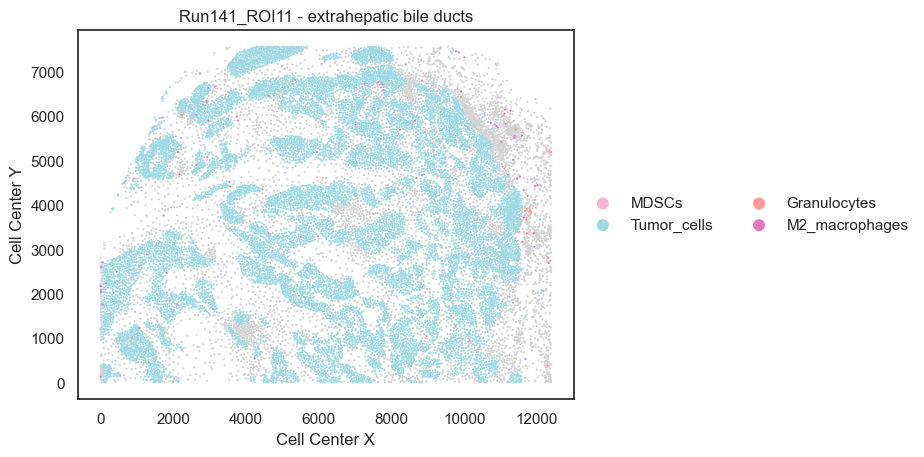

ValueError: 'MDSCs' is invalid! specify valid name, one of Index(['Actin+_cells', 'B_cells', 'CD4+_T_cells', 'CD8+_T_cells',
       'Endothelial_cells', 'Epithelial_cells', 'Granulocytes',
       'Lymphatic_endothelial_cells', 'M1_M2_macrophages', 'M1_macrophages',
       'M2_macrophages', 'Mast_cells', 'NFC', 'NK_cells', 'Plasma_cells',
       'Treg_T_cells', 'Tumor_cells'],
      dtype='object')

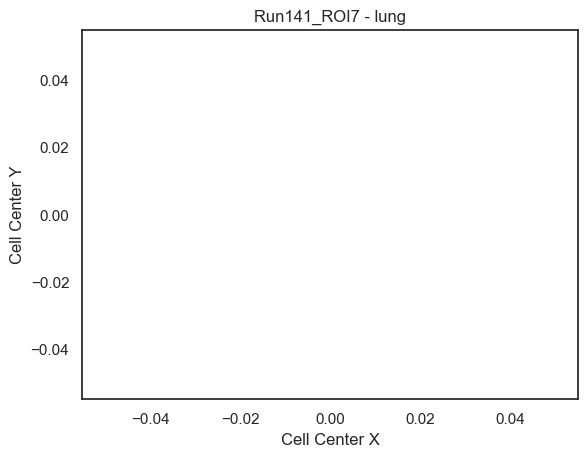

In [26]:
#Make a scatterplot based on the coordinates of the cells for each sample with axes

for exp in adata.obs.exp_name.unique():
    adata_select = adata[adata.obs.exp_name == exp]
    site = adata_select.obs.site.unique()[0]
    sc.pl.scatter(adata_select, x = "Cell Center X", y = "Cell Center Y", color="cell_type", ax=plt.gca(), size=10, palette="tab20", title=f'{exp} - {site}', groups=["MDSCs", "Tumor_cells", "Granulocytes", "M2_macrophages"])

In [ ]:
sc.pp.scale(adata)

In [41]:
adata.var_names

Index(['Actin REAL650', 'Arginase-1 2', 'Bcl 2 REA872', 'beta Actin REAL571',
       'beta Catenin REA480', 'Calponin REA1104', 'CD1c REAL1005',
       'CD3 REA1151', 'CD4 REA1307', 'CD8a REA1024', 'CD11b REA1321',
       'CD11c REA1310', 'CD14 REA1314', 'CD15 VIMC6', 'CD16 REA1324',
       'CD20 Cytoplasmic REAL649', 'CD31 REA1312', 'CD38 REAL719',
       'CD39 EPR20627', 'CD44 DB105', 'CD45 EPR20033', 'CD45RA REAL164',
       'CD45RB REA119', 'CD45RO REA611', 'CD56 REA1326', 'CD57 REA769',
       'CD66 REA1158', 'CD66b REA306', 'CD68 REA1306', 'CD79a REA1168',
       'CD90 REAL677', 'CD90 REAL677 1', 'CD107a REAL653', 'CD107b REA1073',
       'CD134 ACT35', 'CD138 REA929 3', 'CD163 REA1309', 'CD209 REAL690',
       'CD223 REA351', 'CD223 REA351 1', 'CD274 REA1308', 'CD274 REA1308 1',
       'CD276 SP206', 'CD324 REA1319', 'CD326 REA1311',
       'cleaved PARP 1 REA1316', 'Collagen I REAL958', 'CollagenIV 2',
       'CTLA4-CD152 CAL49', 'Cytokeratin 5 6 REAL538', 'Cytokeratin 5 REAL89

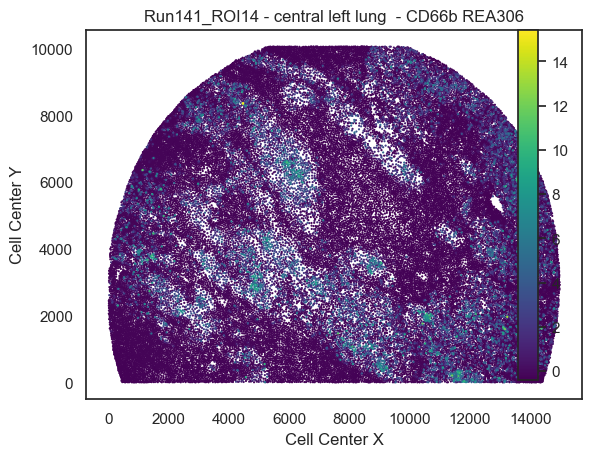

In [75]:
adata_select = adata[adata.obs.exp_name == "Run141_ROI4"]
site = adata_select.obs.site.unique()[0]
sc.pl.scatter(adata_select, x = "Cell Center X", y = "Cell Center Y", color="CD66b REA306", ax=plt.gca(), size=10, title=f'{exp} - {site} - CD66b REA306', color_map="viridis")

calculating foldchange
calculating P values


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:109: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Cervix', 'Cervix', 'Cervix', 'Cervix', 'Cervix', ..., 'Cervix', 'Cervix', 'Cervix', 'Cervix', 'Cervix']
Length: 50825
Categories (1, object): ['Cervix']' has dtype incompatible with category, please explicitly cast to a compatible dtype first.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/foldchange.py:110: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['M2_macrophages', 'M2_macrophages', 'CD8+_T_cells', 'DCs', 'M2_macrophages', ..., 'B_cells', 'Tumor_cells', 'Tumor_cells', 'NFC', 'Tumor_cells']
Length: 50825
Categories (18, object): ['Actin+_cells', 'B_cells', 'CD4+_T_cells'

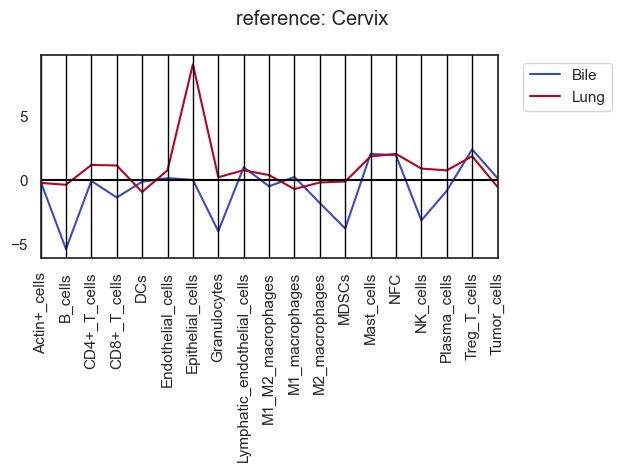

In [121]:
adata = sm.tl.foldchange(adata, from_group='Cervix', imageid='tissue', phenotype='cell_type', normalize=True, label='roi_comparison')
sm.pl.foldchange(adata, label='roi_comparison', method='parallel_coordinates', cmap='coolwarm', log=True,
                 p_val=0.05, nonsig_color='lightgrey')

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3364/2212274136.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



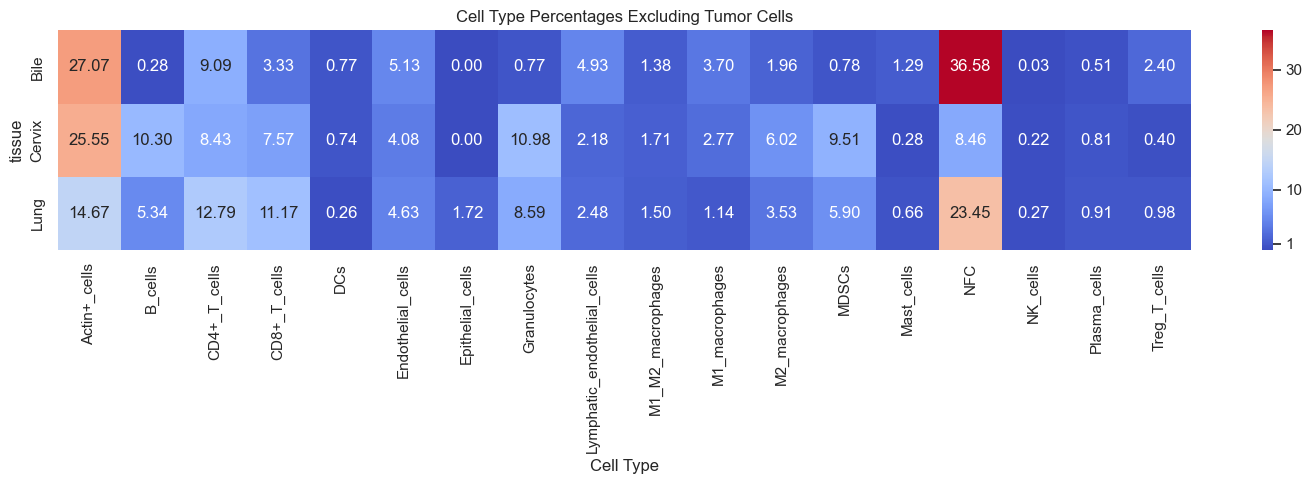

In [137]:
#heatmap for cell type proportions
adata_proportions = adata.obs.groupby(["tissue", "cell_type"]).size().unstack().fillna(0)
#drop the tumor cells column
adata_proportions = adata_proportions.drop(columns="Tumor_cells")
adata_proportions = adata_proportions.div(adata_proportions.sum(axis=1), axis=0).mul(100)
bins = [1, 10, 20, 30, 40]  # Custom thresholds
cmap = sns.color_palette("coolwarm", len(bins) - 1)
plt.figure(figsize=(15, 5))
sns.heatmap(adata_proportions, cbar_kws={"ticks": bins}, annot=True, fmt=".2f", cmap="coolwarm")
#make the x-axis labels at 45 degrees
# plt.ylabel("Tissue")
plt.xlabel("Cell Type")
plt.title("Cell Type Percentages Excluding Tumor Cells")
plt.tight_layout()

## How interactions are similar across all sampless

## Spatial distances

In [49]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y',
                               phenotype='cell_type', 
                               label='2D_distance',
                               imageid="exp_name")

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI1
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI4
Processing Image: Run141_ROI23
Processing Image: Run141_ROI3
Processing Image: Run141_ROI14


Kmeans clustering


AnnData object with n_obs × n_vars = 285428 × 82
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

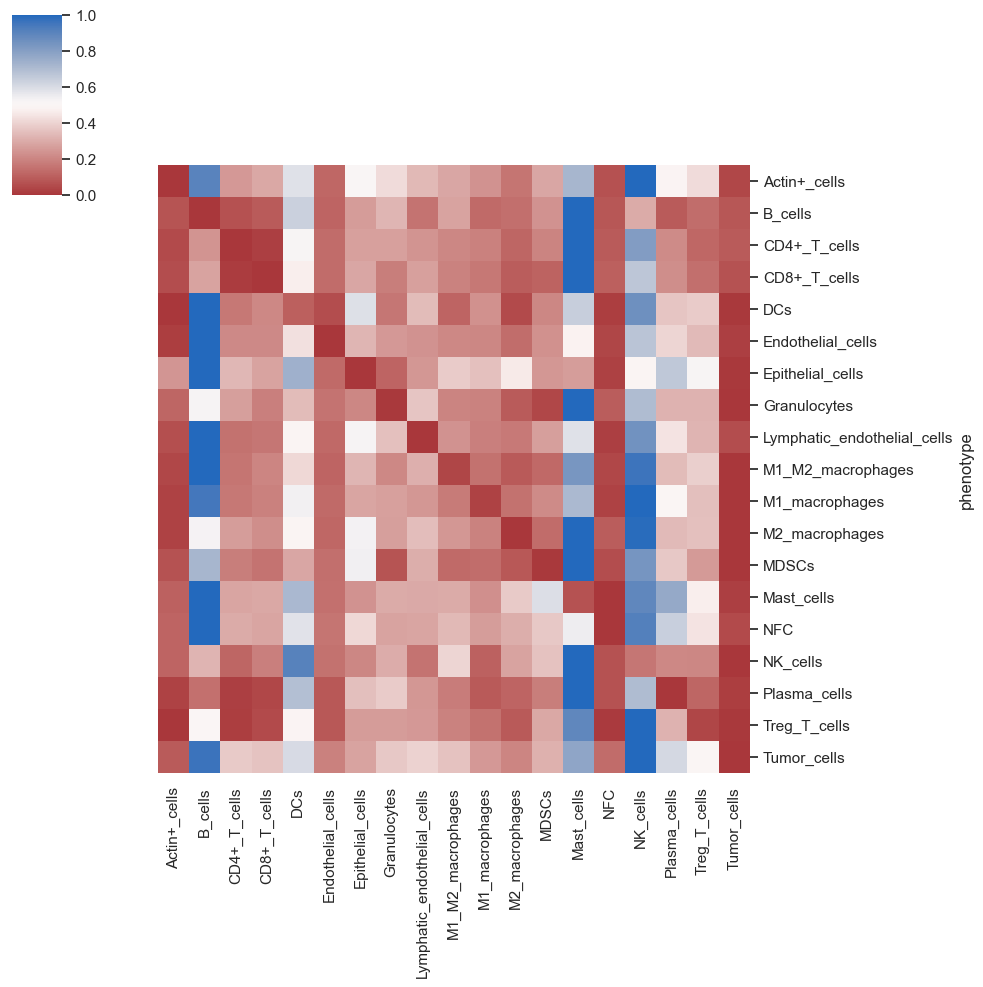

In [51]:
sm.pl.spatial_distance(adata, phenotype='cell_type', imageid='exp_name', spatial_distance="2D_distance", method="heatmap")

## Spatial LDA

In [12]:
sm.tl.spatial_lda(adata, 
                  x_coordinate='Cell Center X', 
                  y_coordinate='Cell Center Y',
                  phenotype="cell_type", 
                  method='knn', 
                  knn=15, 
                  imageid='exp_name', 
                  num_motifs=10, 
                  label='spatial_lda')

Processing: ['Run141_ROI1']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI4']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI3']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI15']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI14']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI8']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI11']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI7']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI16']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI19']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI17']
Identifying the 15 nearest neighbours for every cell
Processing: ['Run141_ROI23']
Identifying the 15 nearest neighbours for every cell
Pre-Processing Spatia

AnnData object with n_obs × n_vars = 285428 × 82
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [ ]:
sm.tl.spatial_cluster(adata, df_name='spatial_lda', method='kmeans', k=6, label='spatial_lda_kmeans')

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_9568/2237259650.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



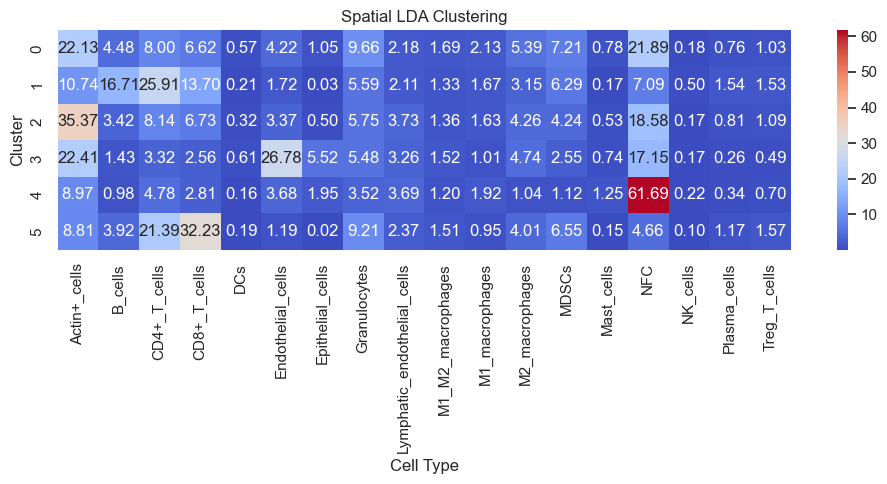

In [26]:
counts = adata.obs.groupby(["spatial_lda_kmeans", "cell_type"]).size().unstack().fillna(0)
counts = counts.drop(columns="Tumor_cells")
counts = counts.div(counts.sum(axis=1), axis=0).mul(100)
plt.figure(figsize=(10, 5))
sns.heatmap(counts, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Spatial LDA Clustering")
plt.xlabel("Cell Type") 
plt.ylabel("Cluster")
plt.tight_layout()

In [52]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_type",
                         method='delaunay',
                         permutation=300,
                         imageid='exp_name',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['Run141_ROI11']
Categories (1, object): ['Run141_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI16']
Categories (1, object): ['Run141_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI7']
Categories (1, object): ['Run141_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI19']
Categories (1, object): ['Run141_ROI19']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Ru

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['Run141_ROI23']
Categories (1, object): ['Run141_ROI23']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI3']
Categories (1, object): ['Run141_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['Run141_ROI14']
Categories (1, object): ['Run141_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 285428 × 82
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

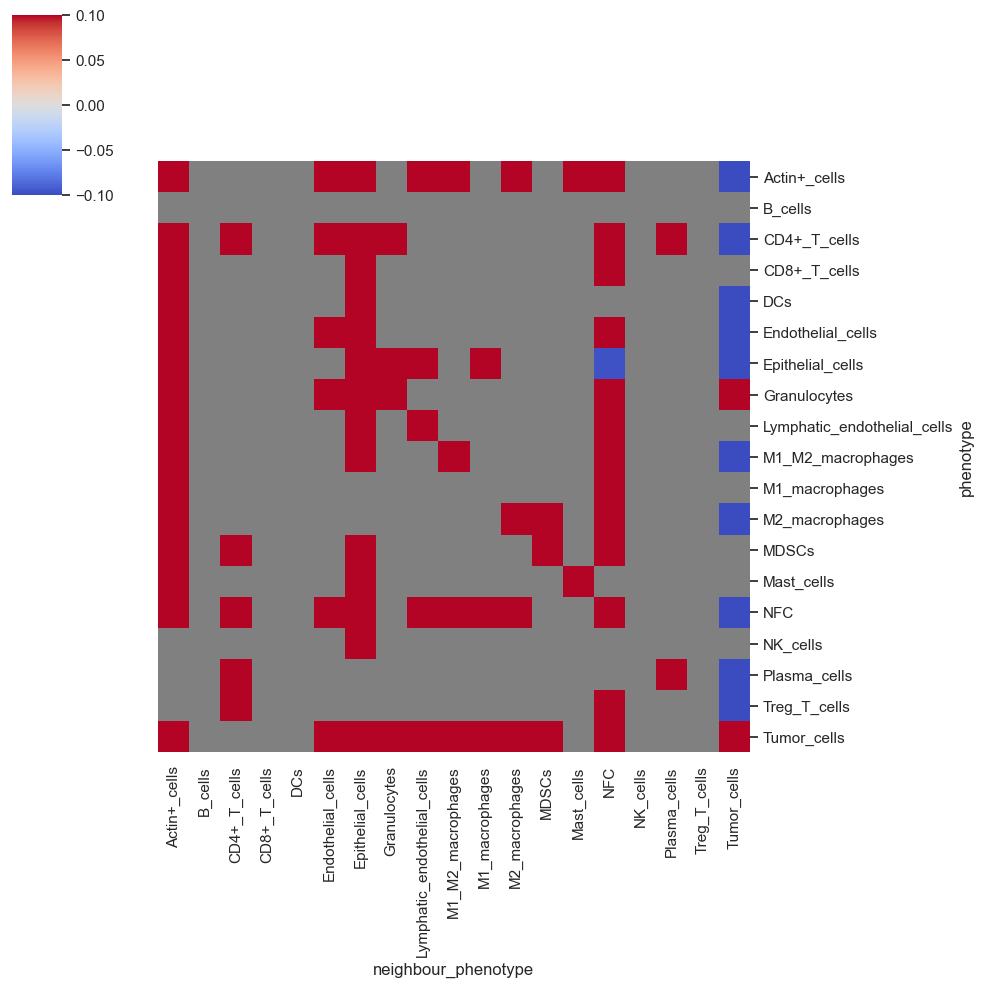

In [54]:
sm.pl.spatial_interaction(adata, p_val=0.1, cmap='coolwarm', spatial_interaction="scimap_delaunay_conditional_zscore")

In [ ]:
heatmap_data = heatmap_data.filter(like="-Tumor_cells", axis=0)

In [71]:
heatmap_data = adata.uns['scimap_delaunay_conditional_zscore']
heatmap_data.index = heatmap_data["phenotype"] + "-" + heatmap_data["neighbour_phenotype"]
heatmap_data= heatmap_data.drop(columns=["phenotype", "neighbour_phenotype"])
heatmap_data = heatmap_data.filter(like='zscore', axis=1)
#filter the index to include only interactions with Tumor_cells
heatmap_data = heatmap_data[~heatmap_data.index.str.contains("M1_M2")]
heatmap_data = heatmap_data.filter(like="Granulocytes", axis=0)
heatmap_data

,zscore_Run141_ROI11,zscore_Run141_ROI16,zscore_Run141_ROI7,zscore_Run141_ROI19,zscore_Run141_ROI1,zscore_Run141_ROI8,zscore_Run141_ROI17,zscore_Run141_ROI15,zscore_Run141_ROI4,zscore_Run141_ROI23,zscore_Run141_ROI3,zscore_Run141_ROI14
Actin+_cells-Granulocytes,3.315463,8.677171,3.623589,6.185015,16.907267,6.081662,21.709365,0.113797,0.316118,19.343760,-6.763466,-2.232760
B_cells-Granulocytes,-0.633103,-0.395175,6.852997,-0.244684,-0.842387,-0.493961,15.480129,-0.781575,-2.439677,-0.280843,28.463920,-0.320309
CD4+_T_cells-Granulocytes,1.828358,8.673267,5.202856,2.452278,15.960940,15.325233,17.126919,10.937750,-2.217787,2.690594,-7.676264,-0.116054
CD8+_T_cells-Granulocytes,-0.917250,6.204132,2.586539,-0.656195,10.686961,5.360441,10.157736,-0.142619,-1.774331,1.000640,-0.694163,-0.116054
DCs-Granulocytes,0.695364,NaN,NaN,0.504253,1.166359,0.865657,4.625216,-0.212474,5.617177,1.522710,6.313266,-0.057735
Endothelial_cells-Granulocytes,0.816571,11.061790,3.079741,-0.669974,16.966987,7.008046,8.533701,0.878956,-0.080321,8.315192,4.038879,-0.607149
Epithelial_cells-Granulocytes,NaN,12.244405,7.276816,NaN,9.932136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Granulocytes-Actin+_cells,0.422393,29.173530,1.311882,13.336394,5.255290,5.416267,17.216241,3.930023,30.836798,6.961705,29.919233,-1.684666
Granulocytes-B_cells,-0.685060,0.181931,-0.219737,-0.266815,-0.896961,-0.540487,21.937780,-0.629636,-3.100778,-0.338906,-11.388059,-0.273894
Granulocytes-CD4+_T_cells,0.194659,6.551723,-0.555764,4.699979,17.080248,6.138037,15.735370,4.690771,5.156098,0.700639,5.750508,-0.081787


In [72]:
ordered_columns = adata.obs.sort_values(by = "outcome_group").loc[:,["exp_name", "outcome_group"]].drop_duplicates().reset_index(drop=True)
z_columns = ["zscore_" + roi for roi in ordered_columns["exp_name"]]
heatmap_data = heatmap_data[z_columns]

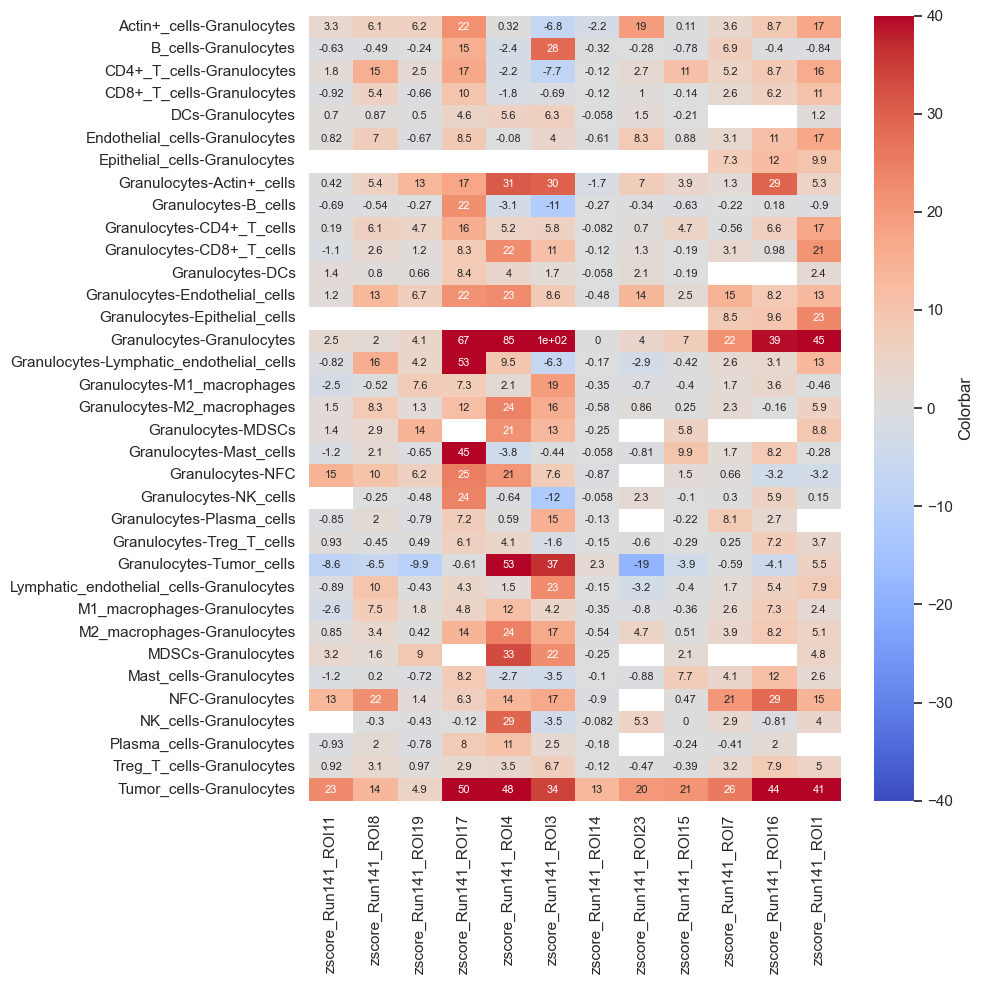

In [73]:
plt.figure(figsize=(10, 10))

# Plot the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    annot_kws={"size": 8},
    cbar_kws={'label': 'Colorbar'},  # Optional, for better colorbar label
    vmin=-40,
    vmax=40
)

# Rotate row labels for better readability
plt.yticks(rotation=0)  # You can adjust this angle as needed (0 for horizontal)

# Adjust layout for better spacing
plt.tight_layout()

plt.show()

In [24]:
adata.obs.loc[:, ["outcome_group", "exp_name", "site"]].drop_duplicates()

,outcome_group,exp_name,site
0,long_term survival,Run141_ROI11,extrahepatic bile ducts
0-1,short_term survival,Run141_ROI16,lung
0-2,short_term survival,Run141_ROI7,lung
0-3,long_term survival,Run141_ROI19,"cervical, A. carotis int. right"
0-4,short_term survival,Run141_ROI1,lung hilus right
0-5,long_term survival,Run141_ROI8,extrahepatic bile ducts
0-6,long_term survival,Run141_ROI17,"cervical, A. carotis int. right"
0-7,short_term survival,Run141_ROI15,"sample: metastasis left tigh, skin \nprimary s..."
0-8,short_term survival,Run141_ROI4,central left lung
0-9,short_term survival,Run141_ROI23,"intrathoracic, right bronchus"


In [12]:
cell_colors = {
    "Tumor_cells": "#FF6347",  # Tomato red
    "Actin+_cells": "grey",  # Steel blue
    "CD8+_T_cells": "#32CD32",  # Lime green
    "M1_macrophages": "#FFD700",  # Gold
    "Treg_T_cells": "#8A2BE2",  # Blue violet
    "M2_macrophages": "#00FA9A",  # Medium spring green
    "DCs": "#FF4500",  # Orange red
    "Endothelial_cells": "#2E8B57",  # Sea green
    "CD4+_T_cells": "#9932CC",  # Dark orchid
    "Mast_cells": "#DAA520",  # Goldenrod
    "Lymphatic_endothelial_cells": "#A52A2A",  # Brown
    "Granulocytes": "#C71585",  # Medium violet red
    "M1_M2_macrophages": "#D2691E",  # Chocolate
    "Plasma_cells": "#8B0000",  # Dark red
    "B_cells": "#4169E1",  # Royal blue
    "MDSCs": "#B22222",  # Firebrick
    "Epithelial_cells": "#228B22",  # Forest green
    "NK_cells": "#FF1493"  # Deep pink
}

In [56]:
adata.obs.outcome_group

0           long_term survival
1           long_term survival
2           long_term survival
3           long_term survival
4           long_term survival
                  ...         
16649-6    short_term survival
16650-6    short_term survival
16651-6    short_term survival
16652-6    short_term survival
16653-6    short_term survival
Name: outcome_group, Length: 179902, dtype: category
Categories (2, object): ['long_term survival', 'short_term survival']

In [13]:
long_term = adata.obs[adata.obs["outcome_group"] == "long_term survival"].exp_name.unique().astype(str)
short_term = adata.obs[adata.obs["outcome_group"] == "short_term survival"].exp_name.unique().astype(str)

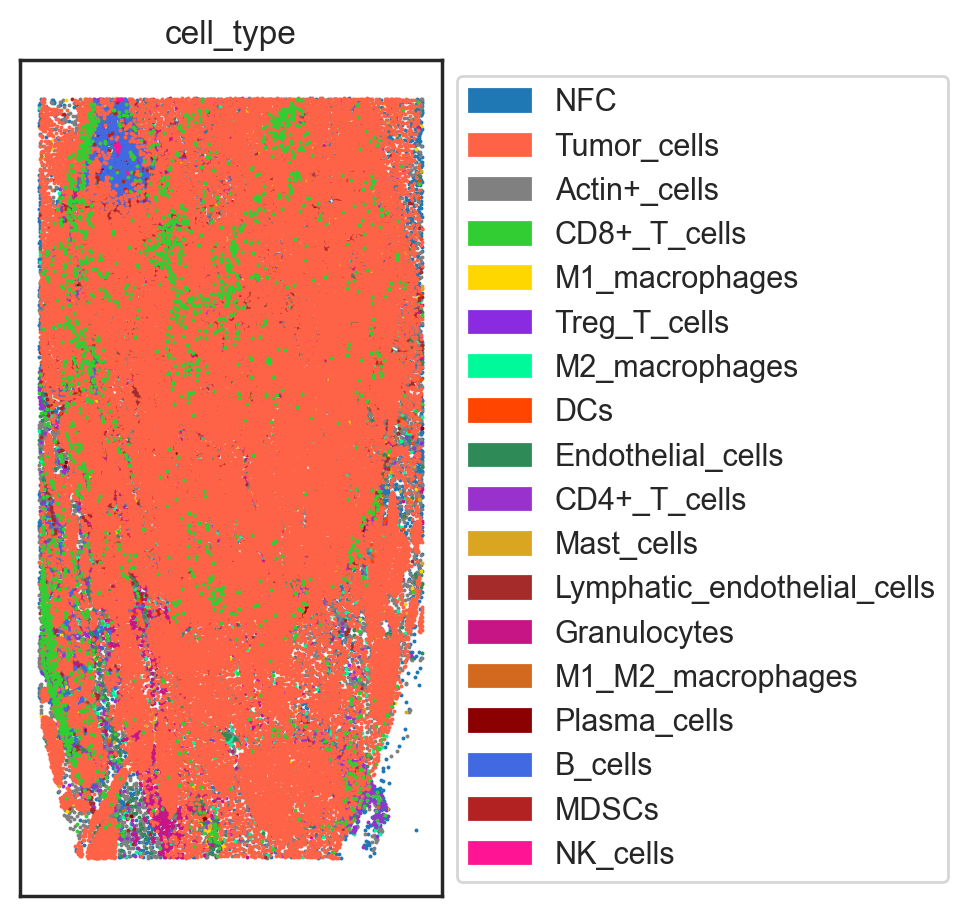

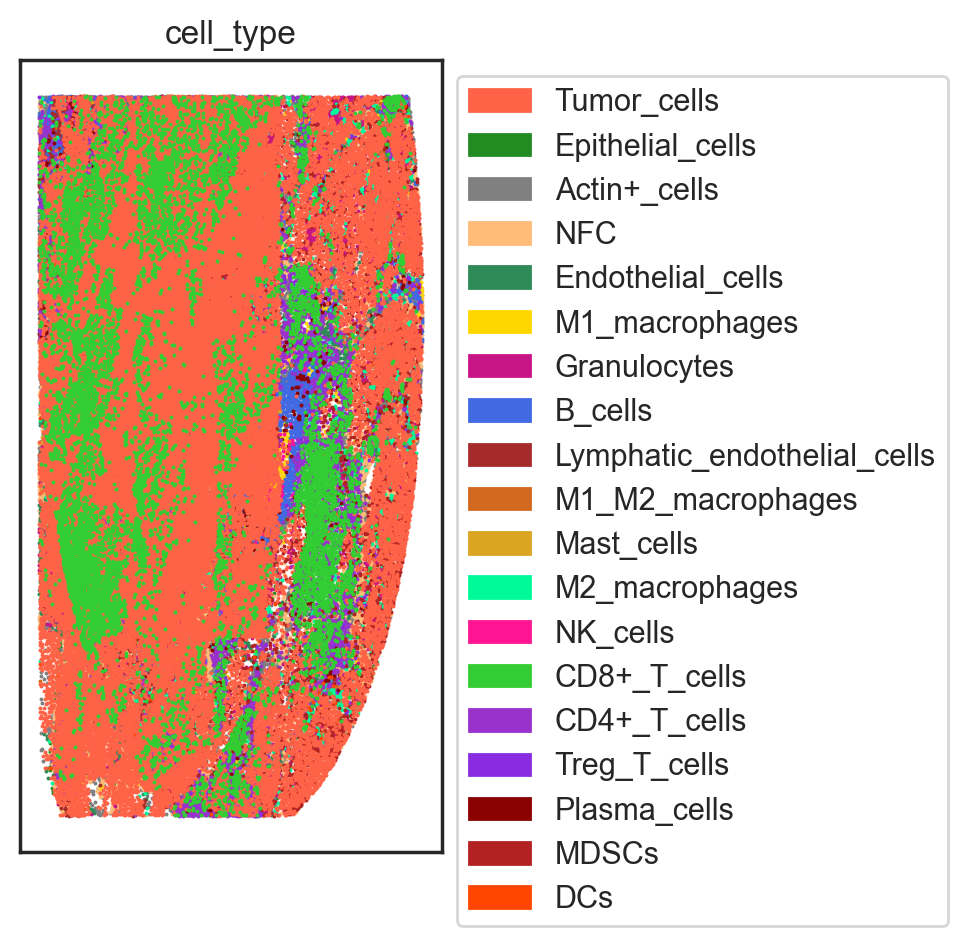

In [15]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)


In [96]:
ordered_columns

['zscore_Run141_ROI11',
 'zscore_Run141_ROI19',
 'zscore_Run141_ROI8',
 'zscore_Run141_ROI17',
 'zscore_Run141_ROI16',
 'zscore_Run141_ROI7',
 'zscore_Run141_ROI15',
 'zscore_Run141_ROI23']

TypeError: object of type 'list_reverseiterator' has no len()

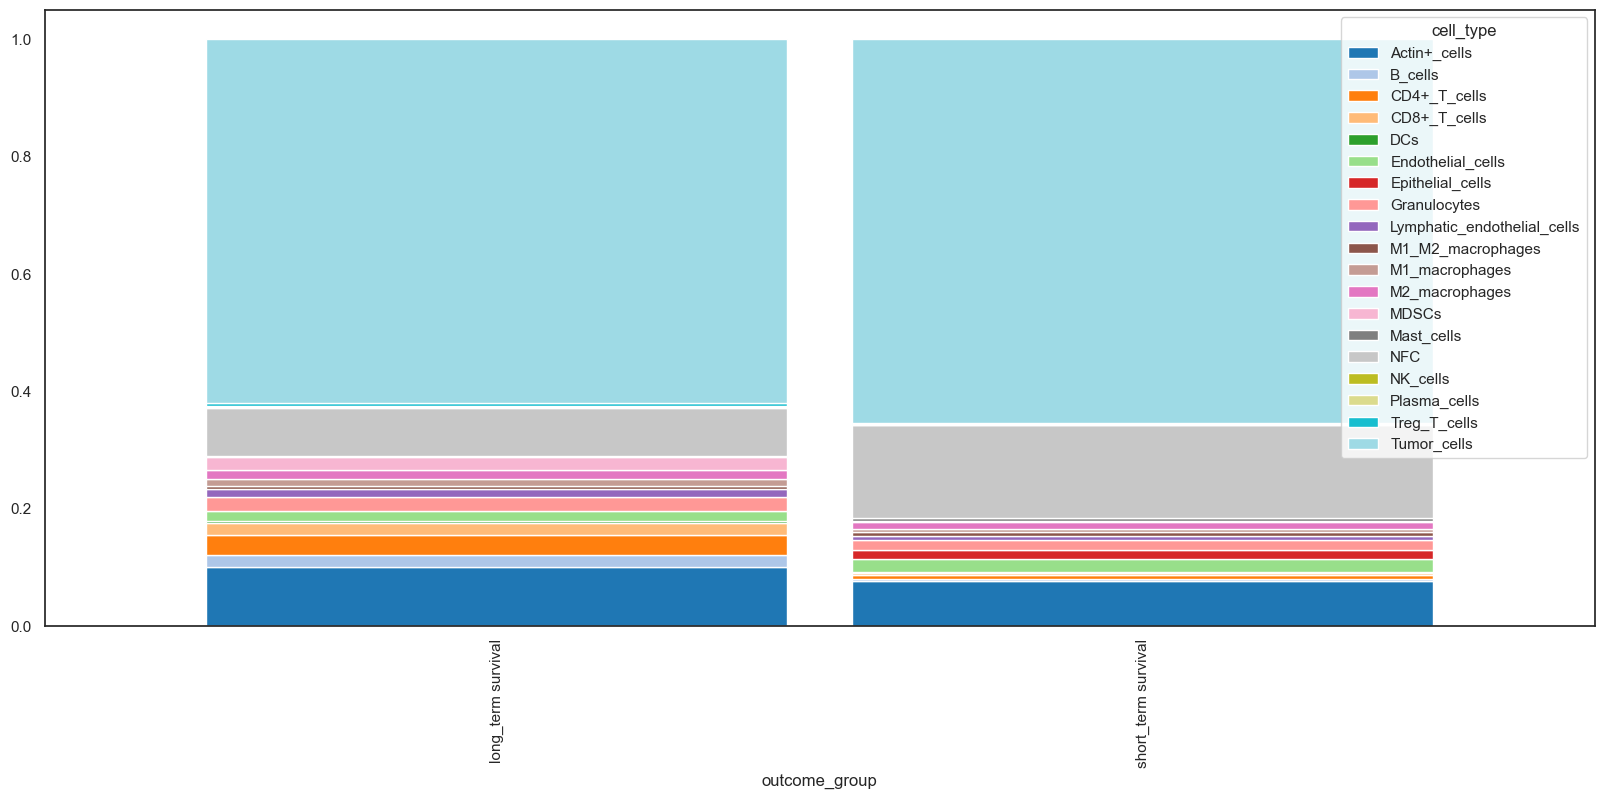

In [115]:
sm.pl.stacked_barplot(adata, x_axis="outcome_group", y_axis="cell_type", method="percent", plot_tool='matplotlib', matplotlib_legend_loc=3, figsize=(20, 8))

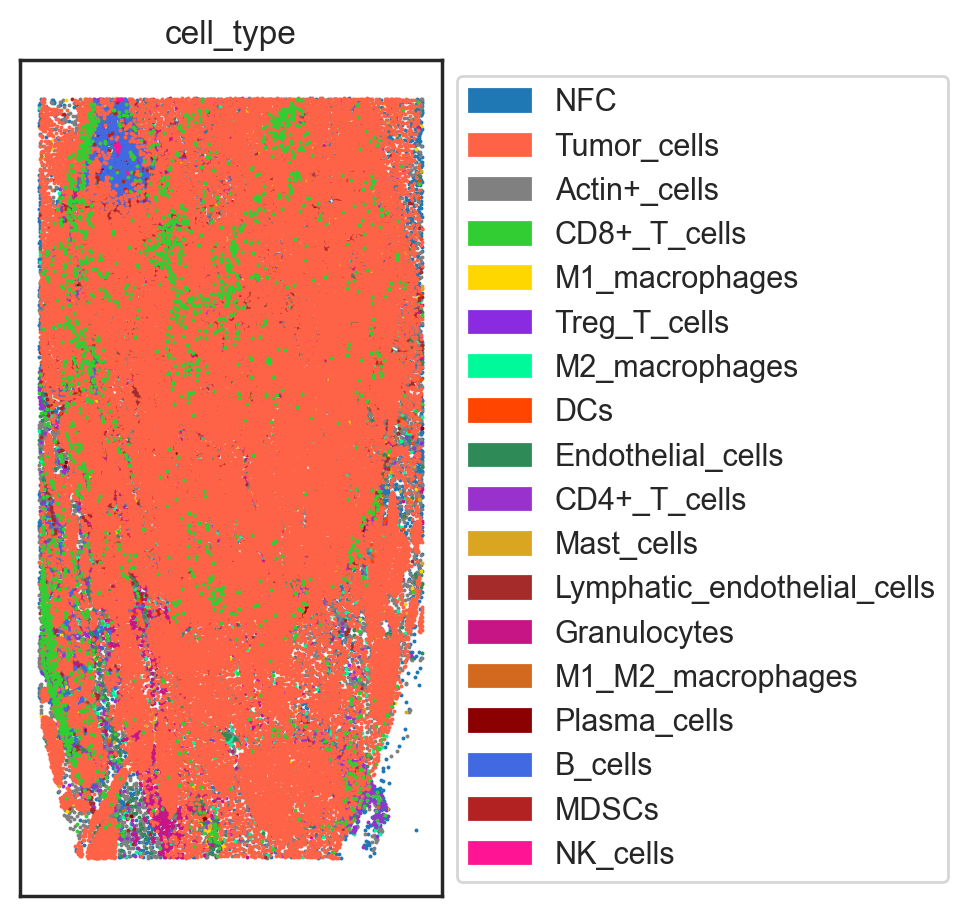

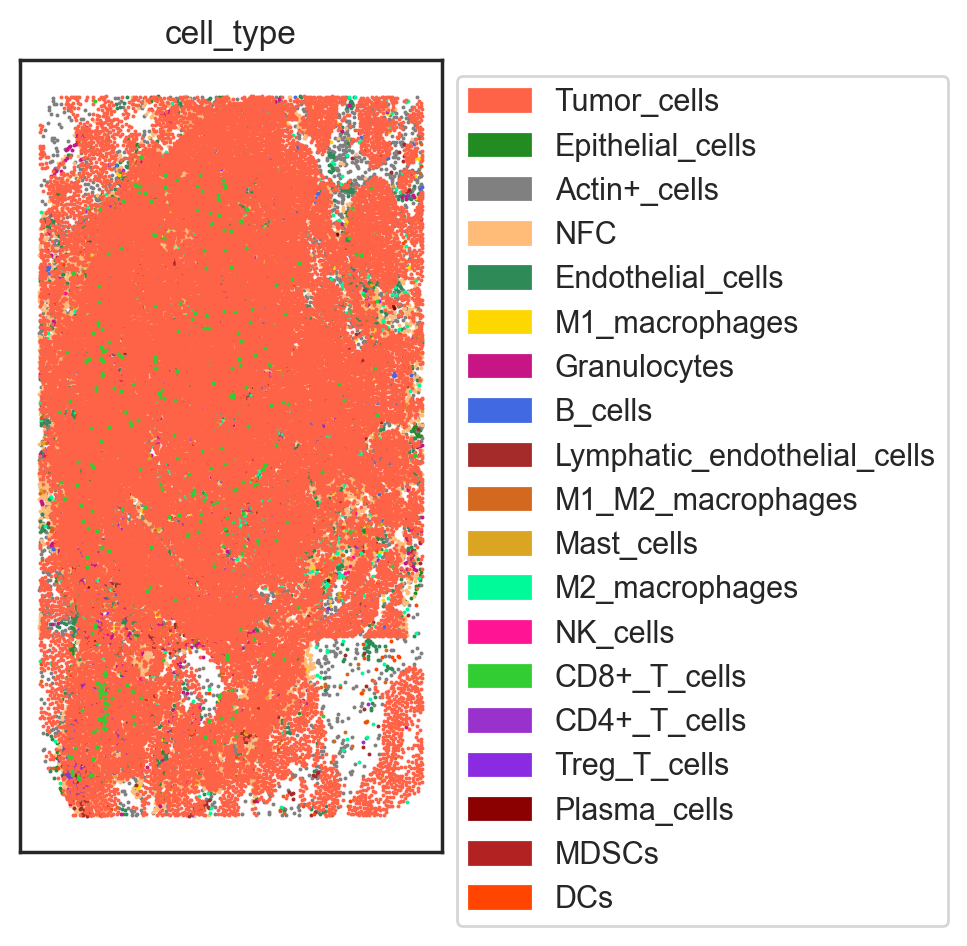

In [70]:
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=long_term, imageid="exp_name", customColors=cell_colors)
sm.pl.spatial_scatterPlot(adata, colorBy="cell_type", x_coordinate="Cell Center X", y_coordinate="Cell Center Y", topLayer=["Tumor_cells", "CD8+_T_cells"], s=2, subset=short_term, imageid="exp_name", customColors=cell_colors)

In [119]:
long_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"]]
short_term_zscore = ["zscore_" + roi for roi in ["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"]]


In [121]:
boxplot_data = heatmap_data.melt(var_name='variable', value_name='value', ignore_index=False)
boxplot_data = boxplot_data.filter(like = "CD8+_T_cells-Tumor_cells", axis=0)
boxplot_data["group"] = np.where(boxplot_data["variable"].isin(long_term_zscore), "Long_term", "Short_term")
boxplot_data


,variable,value,group
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI11,-15.521816,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI19,-8.852351,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI8,-28.027726,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI17,-14.573462,Long_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI16,0.350344,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI7,1.055972,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI15,1.813534,Short_term
CD8+_T_cells-Tumor_cells,zscore_Run141_ROI23,1.628872,Short_term


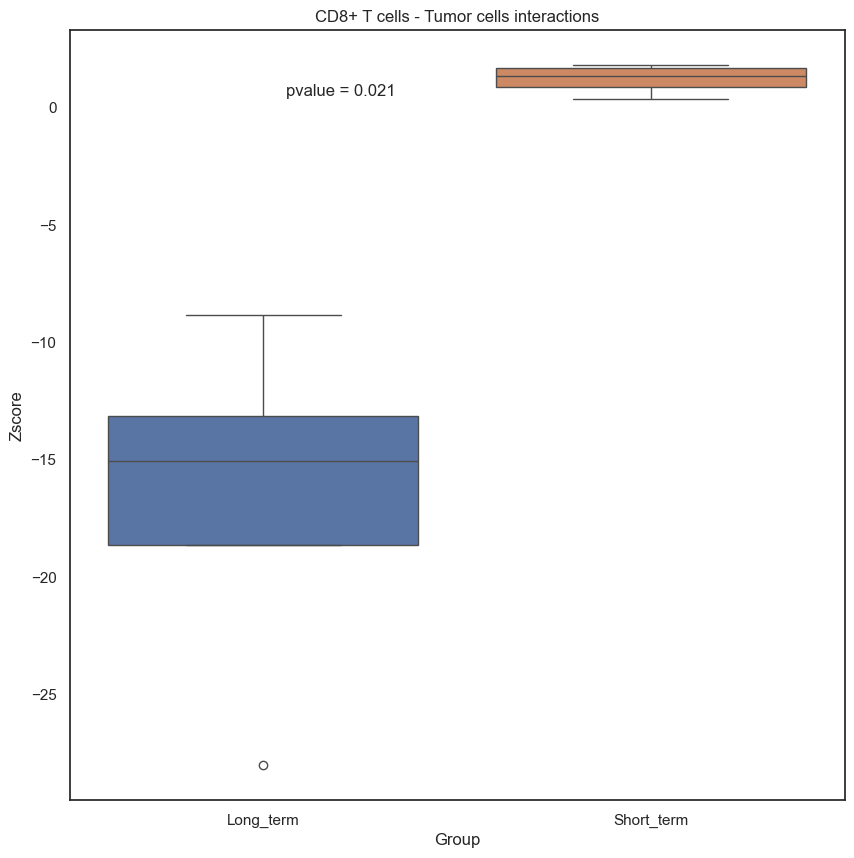

In [136]:
#build a boxplot based on boxplt_data based on matplot
#add the jitter to the boxplot
plt.figure(figsize=(10, 10))
sns.boxplot(x='group', y='value', hue='group', data=boxplot_data)
#add title to box plot and labels
plt.title('CD8+ T cells - Tumor cells interactions')
plt.xlabel('Group')
plt.ylabel('Zscore')
#calculate pvalue based on wilcox and add it to the plot
pvalue = sp.stats.ranksums(boxplot_data[boxplot_data["group"] == "Long_term"]["value"], boxplot_data[boxplot_data["group"] == "Short_term"]["value"]).pvalue.round(3)
plt.text(0.2, 0.5, "pvalue = " + str(pvalue), fontsize=12, ha='center')
plt.show()

In [147]:
adata_long = adata[adata.obs["exp_name"].isin(["Run141_ROI11", "Run141_ROI19", "Run141_ROI8", "Run141_ROI17"])]
adata_short = adata[adata.obs["exp_name"].isin(["Run141_ROI16", "Run141_ROI7", "Run141_ROI15", "Run141_ROI23"])]

In [153]:
adata = sm.tl.spatial_distance(adata, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


In [150]:
adata_long = sm.tl.spatial_distance(adata_long, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')
adata_short = sm.tl.spatial_distance(adata_short, x_coordinate='Cell Center X', y_coordinate='Cell Center Y', imageid='exp_name', subset=None, verbose=True, label='scimap_distance', phenotype='cell_type')

Processing Image: Run141_ROI11
Processing Image: Run141_ROI19
Processing Image: Run141_ROI8
Processing Image: Run141_ROI17
Processing Image: Run141_ROI16
Processing Image: Run141_ROI7
Processing Image: Run141_ROI15
Processing Image: Run141_ROI23


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/scimap/tools/spatial_distance.py:143: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



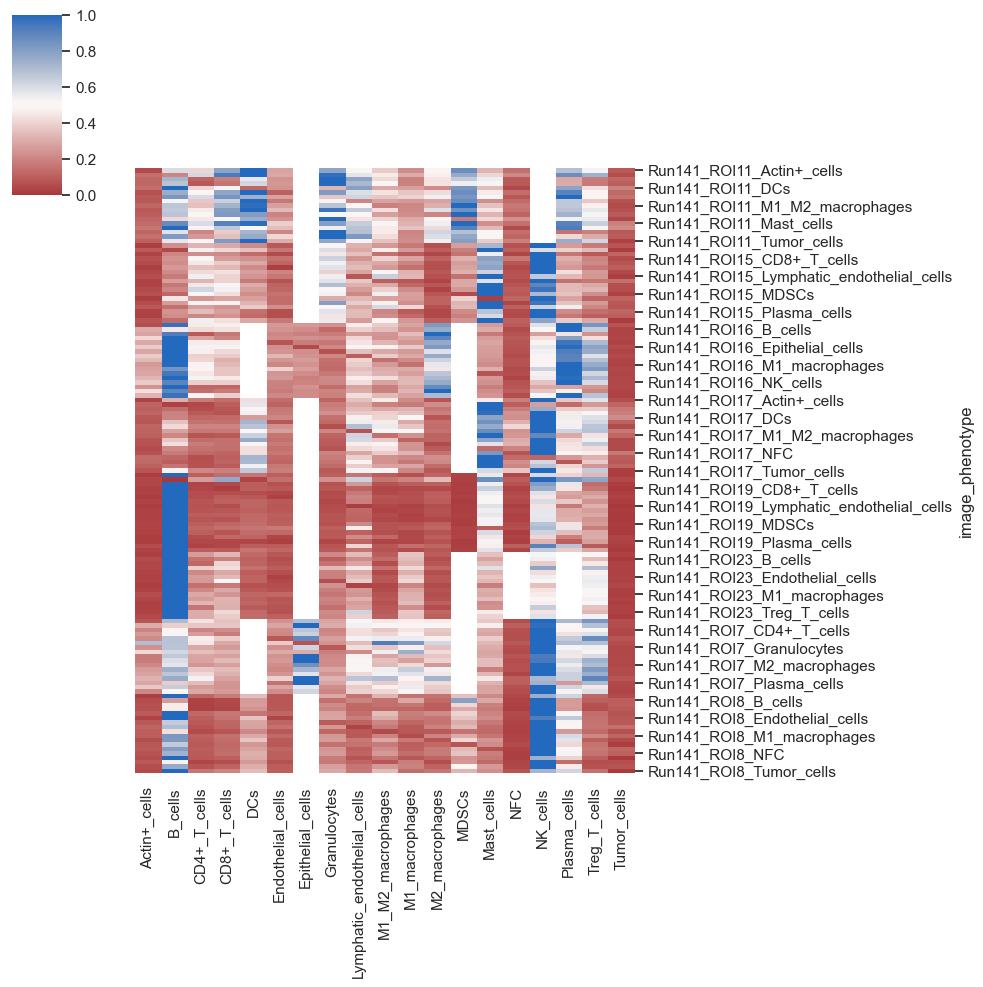

In [157]:
sm.pl.spatial_distance(adata, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance', heatmap_summarize=False)

In [1]:
sm.pl.spatial_distance(adata_long, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')
sm.pl.spatial_distance(adata_short, phenotype="cell_type", imageid="exp_name", spatial_distance='scimap_distance')


NameError: name 'sm' is not defined